## Task1 - Race bias analysis

Goal: Check whether perceived traits differ across race groups
(White, Black, East Asian) using descriptive statistics and one-way ANOVA.

In [ ]:
import pandas as pd
import numpy as np

from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv(
    "data.csv"
)

df.head()

,Filename,Image #,Gender,Race,Confident,Egotistic,Intelligent,Kind,Responsible,Trustworthy,Aggressive,Caring,Emotional,Friendly,Sociable,Qualified
0,Google_1_Danielle Goble_5_oval.jpg,1,1,1,5.67,3.67,5.60,5.00,5.80,5.33,4.80,4.67,3.67,4.33,4.67,0
1,Google_1_Phillip Owensby_9_oval.jpg,2,0,1,6.53,2.20,6.60,7.00,7.47,6.73,3.13,6.93,5.80,6.73,6.60,1
2,Google_1_Douglas Ziegler_3_oval.jpg,3,1,1,6.07,3.60,6.47,6.47,6.67,6.40,2.40,6.07,5.14,6.67,6.67,0
3,Google_1_Donald Sauls_11_oval.jpg,4,1,2,4.80,4.60,4.47,3.80,4.27,3.87,5.80,3.53,2.80,2.93,3.27,0
4,Google_1_Eric Harman_5_oval.jpg,5,1,6,6.67,5.40,6.33,4.87,5.87,4.67,4.27,4.07,4.80,5.20,5.33,1


In [12]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2222 entries, 0 to 2221
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Filename     2222 non-null   object 
 1   Image #      2222 non-null   int64  
 2   Gender       2222 non-null   int64  
 3   Race         2222 non-null   int64  
 4   Confident    2222 non-null   float64
 5   Egotistic    2222 non-null   float64
 6   Intelligent  2222 non-null   float64
 7   Kind         2222 non-null   float64
 8   Responsible  2222 non-null   float64
 9   Trustworthy  2222 non-null   float64
 10  Aggressive   2222 non-null   float64
 11  Caring       2222 non-null   float64
 12  Emotional    2222 non-null   float64
 13  Friendly     2222 non-null   float64
 14  Sociable     2222 non-null   float64
 15  Qualified    2222 non-null   int64  
dtypes: float64(11), int64(4), object(1)
memory usage: 277.9+ KB


Index(['Filename', 'Image #', 'Gender', 'Race', 'Confident', 'Egotistic',
       'Intelligent', 'Kind', 'Responsible', 'Trustworthy', 'Aggressive',
       'Caring', 'Emotional', 'Friendly', 'Sociable', 'Qualified'],
      dtype='object')

In [18]:
df["Race"].unique()

array([1, 2, 6, 5, 3, 4, 0])

In [19]:
# Correct column name
race_col = "Race"

# Use numeric codes (based on your sample)
race_groups = [1, 2, 6]   # adjust if needed

# Correct trait names (capitalized!)
traits = [
    "Confident", "Egotistic", "Intelligent", "Kind", "Responsible",
    "Trustworthy", "Aggressive", "Caring", "Emotional", "Friendly", "Sociable"
]

# Filter data
df_race = df[df[race_col].isin(race_groups)].copy()

# Drop missing values
df_race = df_race.dropna(subset=[race_col] + traits)

# Check result
df_race[race_col].value_counts()

Race
1    1836
2     220
6      24
Name: count, dtype: int64

In [20]:
summary_mean = df_race.groupby(race_col)[traits].mean()
summary_median = df_race.groupby(race_col)[traits].median()

print("Mean by race")
display(summary_mean)

print("Median by race")
display(summary_median)

Mean by race


,Confident,Egotistic,Intelligent,Kind,Responsible,Trustworthy,Aggressive,Caring,Emotional,Friendly,Sociable
Race,,,,,,,,,,,
1,5.925109,4.057195,5.863676,5.715496,5.905479,5.645065,3.636961,5.580169,4.869951,5.867516,5.851906
2,5.967909,4.322545,5.528636,5.404500,5.514227,5.346682,4.128409,5.305455,4.732318,5.498636,5.647455
6,5.939167,4.092917,6.049583,5.619167,5.849167,5.413333,3.678750,5.368750,4.940000,5.730417,5.641250


Median by race


,Confident,Egotistic,Intelligent,Kind,Responsible,Trustworthy,Aggressive,Caring,Emotional,Friendly,Sociable
Race,,,,,,,,,,,
1,6.030,4.0,6.00,5.930,6.07,5.800,3.40,5.800,4.87,6.19,6.07
2,6.130,4.2,5.70,5.835,5.80,5.670,3.73,5.730,4.73,5.93,6.13
6,6.035,4.1,5.87,5.530,5.90,5.565,3.63,5.565,4.93,5.90,5.80


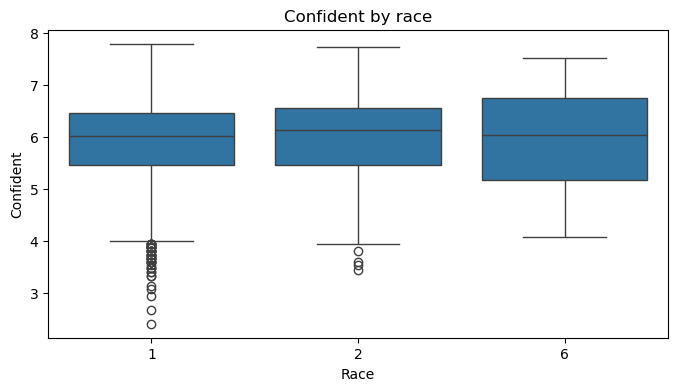

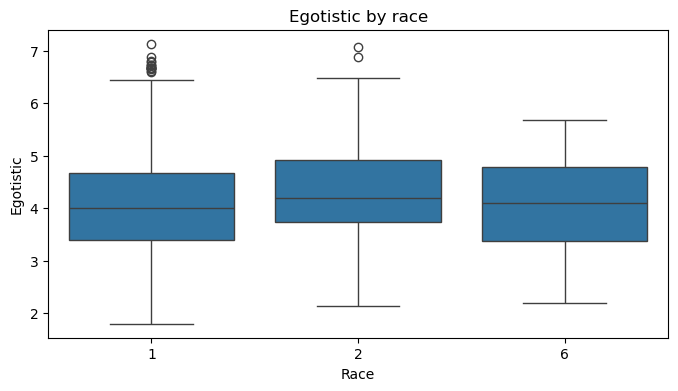

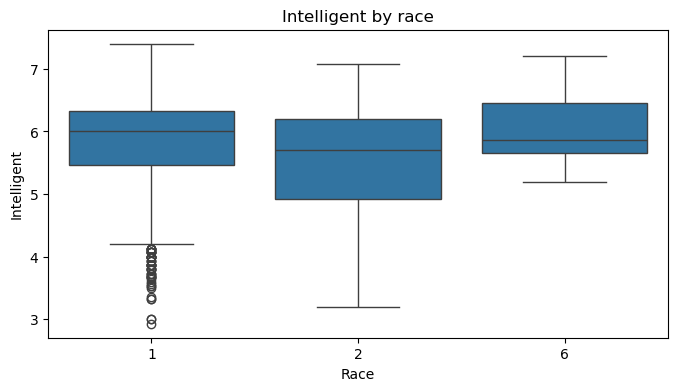

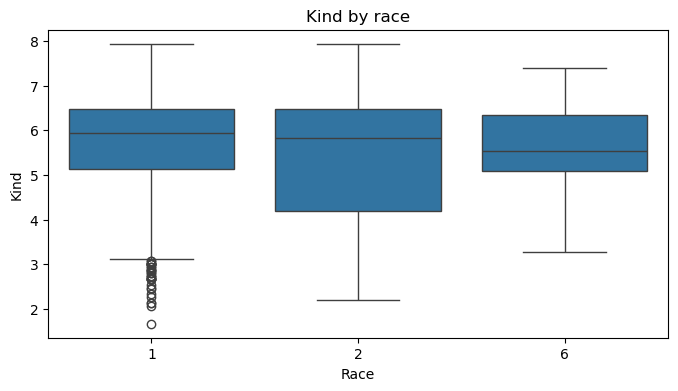

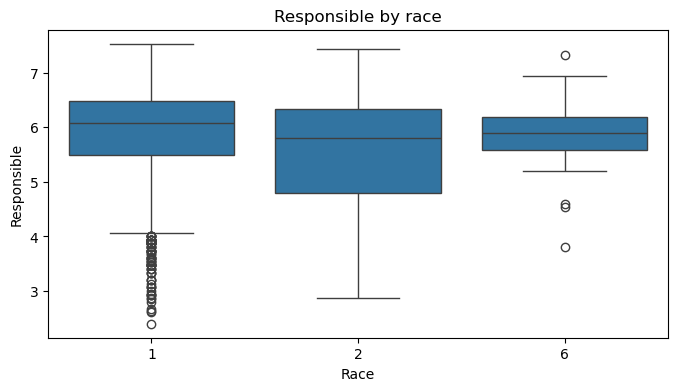

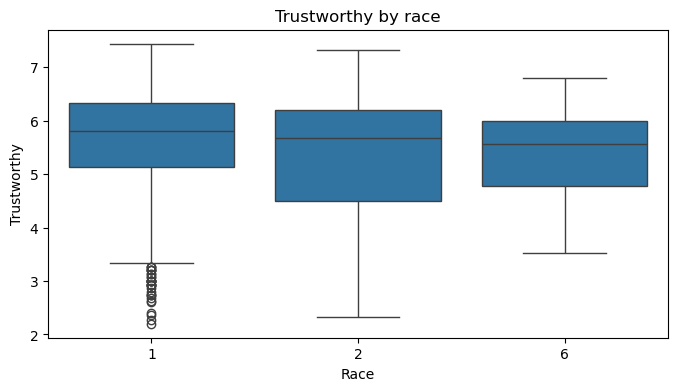

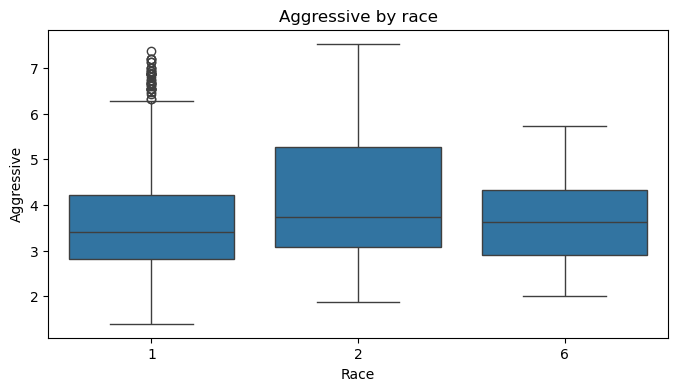

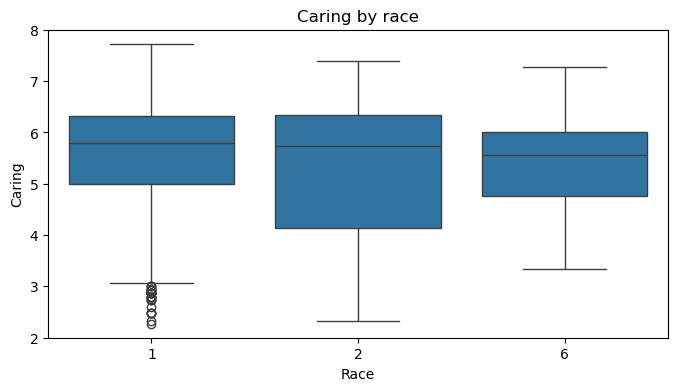

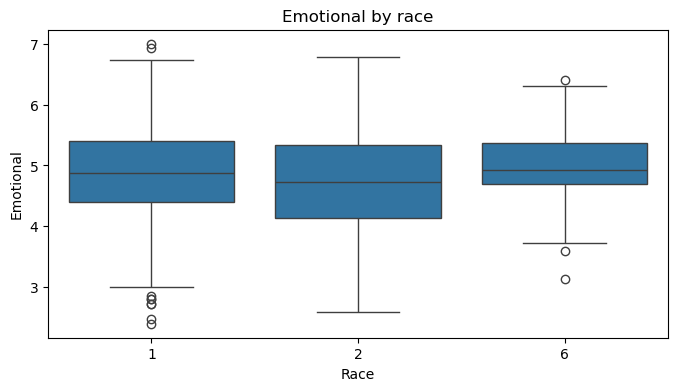

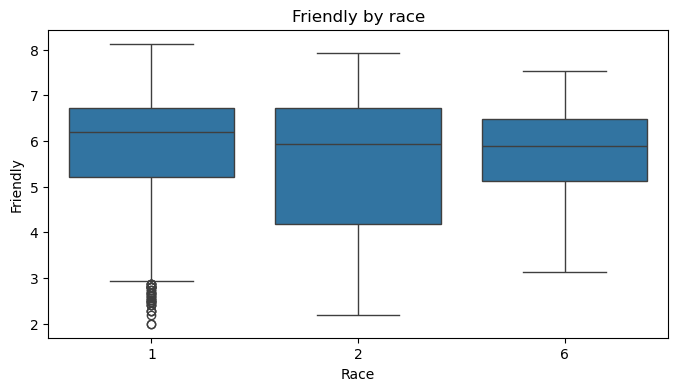

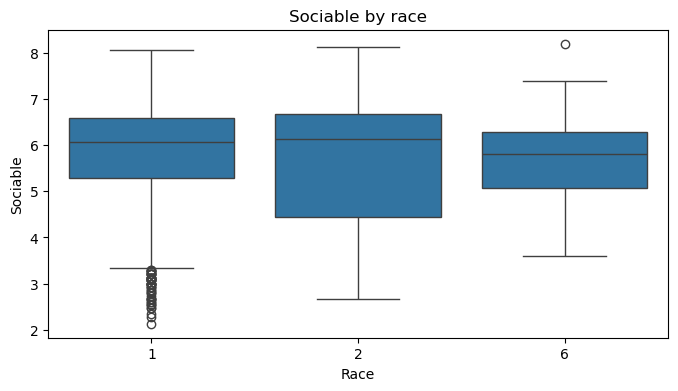

In [21]:
for trait in traits:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_race, x=race_col, y=trait, order=race_groups)
    plt.title(f"{trait} by race")
    plt.show()

In [22]:
anova_results = []

for trait in traits:
    group_data = [df_race[df_race[race_col] == g][trait] for g in race_groups]
    f_stat, p_val = stats.f_oneway(*group_data)
    
    anova_results.append({
        "trait": trait,
        "F-statistic": f_stat,
        "p-value": p_val
    })

anova_df = pd.DataFrame(anova_results).sort_values("p-value")
display(anova_df)

,trait,F-statistic,p-value
2,Intelligent,21.852255,4.056537e-10
4,Responsible,20.026616,2.428567e-09
6,Aggressive,19.088049,6.101409e-09
5,Trustworthy,10.777048,2.206513e-05
9,Friendly,9.056086,1.213504e-04
3,Kind,8.213632,2.798321e-04
1,Egotistic,7.827747,4.103938e-04
7,Caring,7.004204,9.296622e-04
8,Emotional,3.879304,2.081510e-02
10,Sociable,3.694352,2.502710e-02


In [23]:
alpha = 0.05
significant_traits = anova_df[anova_df["p-value"] < alpha]
display(significant_traits)

,trait,F-statistic,p-value
2,Intelligent,21.852255,4.056537e-10
4,Responsible,20.026616,2.428567e-09
6,Aggressive,19.088049,6.101409e-09
5,Trustworthy,10.777048,2.206513e-05
9,Friendly,9.056086,1.213504e-04
3,Kind,8.213632,2.798321e-04
1,Egotistic,7.827747,4.103938e-04
7,Caring,7.004204,9.296622e-04
8,Emotional,3.879304,2.081510e-02
10,Sociable,3.694352,2.502710e-02
